In [1]:
# Advertising Sales Prediction Project
# 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
# 2: Load Dataset
df = pd.read_csv("/content/advertising.csv")

print("First 5 Rows of Dataset")
print(df.head())

First 5 Rows of Dataset
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


In [3]:
# 3: Dataset Information
print("\nDataset Info")
print(df.info())

print("\nStatistical Summary")
print(df.describe())


Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

Statistical Summary
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


In [4]:
# 4: Check Missing Values
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


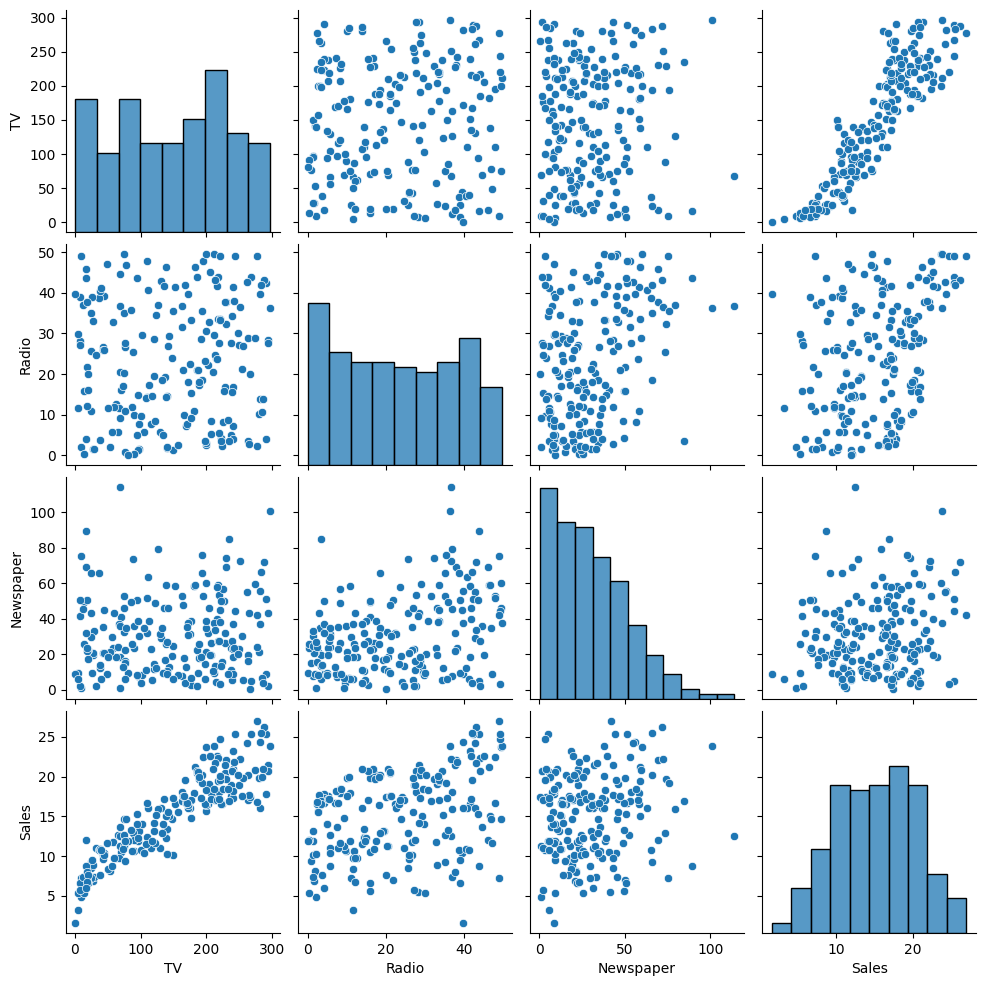

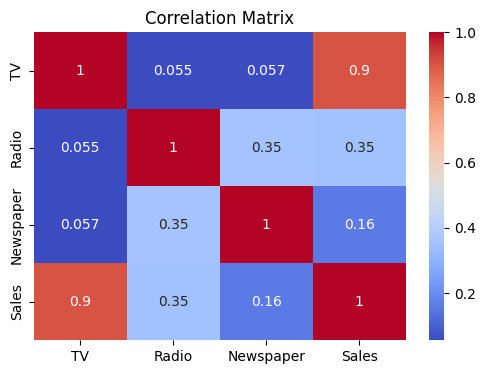

In [5]:
# 5: Data Visualization

# Pairplot
sns.pairplot(df)
plt.show()

# Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [6]:
# 6: Define Features and Target
X = df[['TV','Radio','Newspaper']]   # Independent Variables
y = df['Sales']                      # Dependent Variable

In [7]:
# 7: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# 8: Train Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [9]:
# 9: Make Predictions
y_pred = model.predict(X_test)


In [10]:
# 10: Model Evaluation
print("\nModel Evaluation")

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)


Model Evaluation
Mean Absolute Error: 1.2748262109549338
Mean Squared Error: 2.9077569102710896
R2 Score: 0.9059011844150826


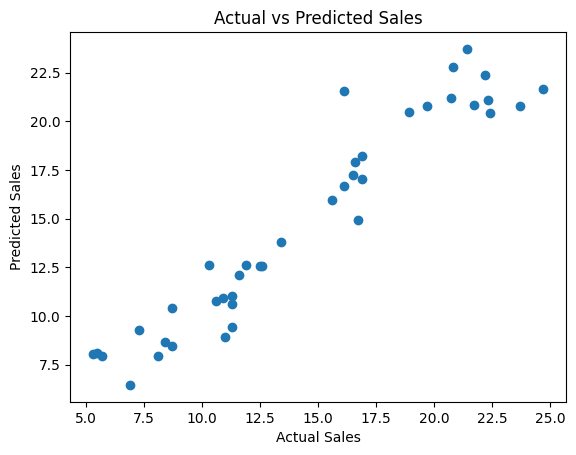

In [11]:
# 11: Actual vs Predicted Graph
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [12]:
# 12: Model Coefficients
print("\nModel Coefficients")
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coefficients)

print("\nIntercept:", model.intercept_)


Model Coefficients
           Coefficient
TV            0.054509
Radio         0.100945
Newspaper     0.004337

Intercept: 4.714126402214127
